In [1]:
# tutorial de https://www.geeksforgeeks.org/python/working-csv-files-python/

import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter,StrMethodFormatter
import glob
import os
import numpy as np
import seaborn as sns

In [2]:
def getData(ruta):
    patronArchivos = os.path.join(ruta, "*.csv") # string con formato ruta/*.csv
    archivos = glob.glob(patronArchivos) #encuentra todo lo que matchea el patrón
    
    archivos = sorted(archivos)
    promedios = np.zeros(len(archivos))
    
    
    for i, archivo in enumerate(archivos):
        tempDf = pd.read_csv(archivo,
                             sep = ';',
                             decimal = ',',
                             encoding='latin-1')
                            
    
        
    return tempDf

In [3]:
def graficar(datos):

    lugares = datos['UBICACIÓN'].unique()

    # Crea un nuevo DataFrame solo con esas filas
    resultado = datos[datos['UBICACIÓN'] == '150']
    


    # 1. Convertir fecha y ordenar
    datos['FECHA'] = pd.to_datetime(datos['FECHA'], dayfirst=True)
    datos = datos.sort_values('FECHA')
    
    # 2. Configurar la figura (2 filas, 2 columnas)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
    ubicacion = datos['UBICACIÓN'].iloc[0]
    fig.suptitle(f'Análisis de Variables para Ubicación: {ubicacion}', fontsize=16)
    
    # 3. Graficar cada variable
    # Cloro
    axs[0, 0].plot(datos['FECHA'], datos['CLORO'], marker='o', color='blue')
    axs[0, 0].set_title('Cloro')
    axs[0, 0].set_ylabel('mg/l')
    axs[0, 0].set_ylim(0, 1)
    
    # Turbiedad
    axs[0, 1].plot(datos['FECHA'], datos['TURBIEDAD'], marker='s', color='orange')
    axs[0, 1].set_title('Turbiedad')
    axs[0, 1].set_ylabel('NTU')
    axs[0, 1].set_ylim(0, 1.2)
    
    # pH
    axs[1, 0].plot(datos['FECHA'], datos['PH'], marker='^', color='green')
    axs[1, 0].set_title('pH')
    axs[1, 0].set_ylabel('Unidades pH')
    axs[1, 0].set_ylim(5.5, 8)
    
    # Temperatura
    axs[1, 1].plot(datos['FECHA'], datos['TEMPERATURA'], marker='x', color='red')
    axs[1, 1].set_title('Temperatura')
    axs[1, 1].set_ylabel('°C')
    axs[1, 1].set_ylim(15, 24)
    
    # Formato estético
    for ax in axs.flat:
        ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.xticks(rotation=45)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
        


    

In [4]:
def graficarCajas(df):
    # ── 0. Rangos físicamente válidos ────────────────────────────────────────
    rangos_validos = {
        'CLORO':       (0.0,  5.0),
        'TURBIEDAD':   (0.0, 50.0),
        'PH':          (3.0, 11.0),
        'TEMPERATURA': (0.0, 40.0),
    }

    # ── 1. Configuración de datos y variables ────────────────────────────────
    variables = ['CLORO', 'TURBIEDAD', 'PH', 'TEMPERATURA']
    unidades  = ['mg/L',  'NTU',       'pH', '°C']
    titulos   = ['Cloro', 'Turbiedad', 'pH', 'Temperatura']

    lugares = df['UBICACIÓN'].unique()

    # ── 2. Crear la figura ───────────────────────────────────────────────────
    fig, axs = plt.subplots(len(lugares), 4,
                            figsize=(18, 5 * len(lugares)),
                            squeeze=False)

    for i, loc in enumerate(lugares):
        df_loc = df[df['UBICACIÓN'] == loc].copy()

        for j, (var, unidad, titulo) in enumerate(zip(variables, unidades, titulos)):
            ax = axs[i, j]

            # ── Paso 1: filtro físico ────────────────────────────────────────
            lo, hi = rangos_validos[var]
            data_valida = df_loc[var].dropna()
            data_valida = data_valida[data_valida.between(lo, hi)]

            # ── Paso 2: filtro IQR (sobre datos ya válidos) ──────────────────
            if len(data_valida) >= 4:
                Q1  = data_valida.quantile(0.25)
                Q3  = data_valida.quantile(0.75)
                IQR = Q3 - Q1
                data_limpia = data_valida[
                    data_valida.between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
                ]
            else:
                data_limpia = data_valida   # muy pocos datos, no filtrar

            if data_limpia.empty:
                ax.text(0.5, 0.5, 'Sin datos', transform=ax.transAxes,
                        ha='center', va='center', fontsize=11, color='gray')
                ax.set_title(titulo if i == 0 else "", fontsize=14, fontweight='bold')
                continue

            # ── Paso 3: métricas sobre datos limpios ─────────────────────────
            promedio  = data_limpia.mean()
            v_max     = data_limpia.max()
            v_min     = data_limpia.min()
            n_out_fis = len(df_loc[var].dropna()) - len(data_valida)   # outliers físicos
            n_out_iqr = len(data_valida) - len(data_limpia)             # outliers IQR
            n_out_tot = n_out_fis + n_out_iqr
            n_orig    = len(df_loc[var].dropna())
            pct_out   = (n_out_tot / n_orig * 100) if n_orig > 0 else 0

            # ── Paso 4: gráfico ──────────────────────────────────────────────
            sns.boxplot(
                y=data_limpia, ax=ax,
                color='skyblue', width=0.5,
                showmeans=True,
                meanprops={"marker": "o", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 8},
                showfliers=False
            )

            # ── Paso 5: anotaciones ──────────────────────────────────────────
            u = "" if var == 'PH' else f' {unidad}'
            texto_stats = (
            f'Media: {promedio:.2f}{u}\n'
            f'Máx:   {v_max:.2f}{u}\n'
            f'Mín:   {v_min:.2f}{u}\n'
            f'Outliers: {pct_out:.1f}%'
            )
            
            ax.text(1.05, 0.5, texto_stats,
                    transform=ax.transAxes,
                    fontsize=9, verticalalignment='center', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

            # ── Paso 6: títulos y etiquetas ──────────────────────────────────
            if i == 0:
                ax.set_title(titulo, fontsize=14, fontweight='bold')

            # Unidades en el eje Y de TODAS las columnas (no solo la primera)
            etiqueta_y = titulo if var == 'PH' else f'{titulo} ({unidad})'
            ax.set_ylabel(etiqueta_y, fontsize=10)

            if j == 0:
                ax.set_xlabel(f'Ubicación {loc}', fontweight='bold', fontsize=11)
            else:
                ax.set_xlabel("")

            ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

In [5]:
datos=getData('./')


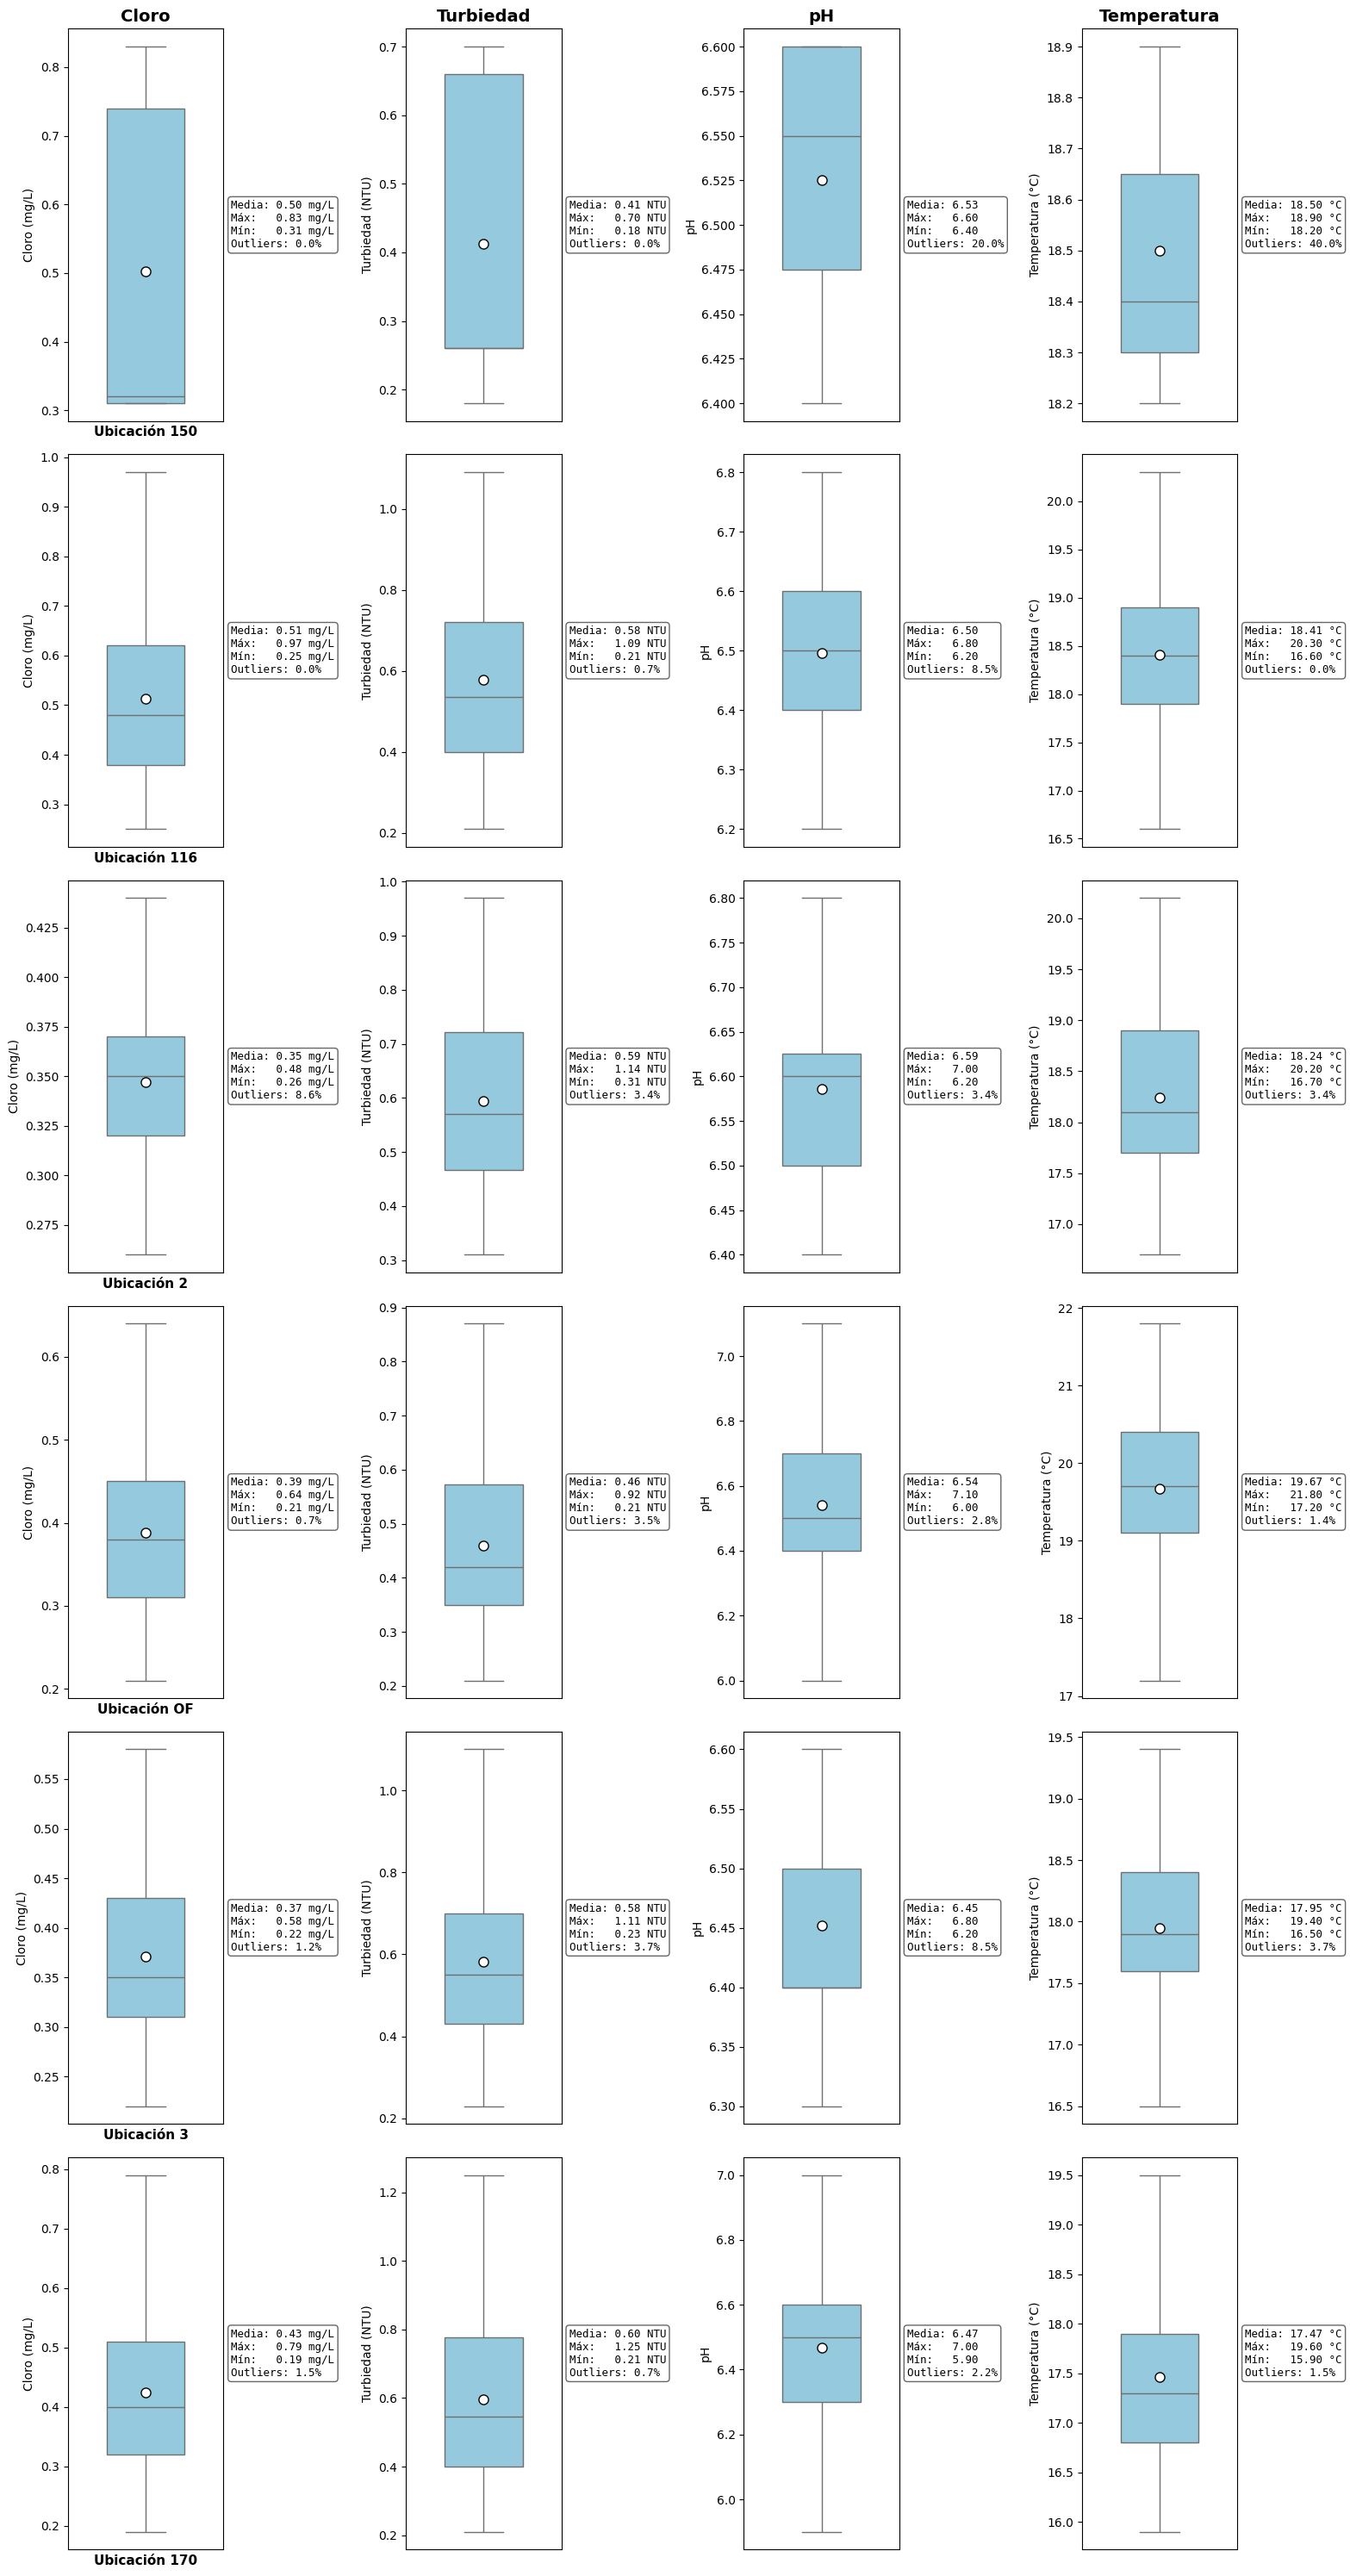

In [6]:
graficarCajas(datos)

In [9]:
print("hello")

hello
